In [364]:
from utils import *

import numpy as np
import pandas as pd
import scipy.signal as signal
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from collections import defaultdict

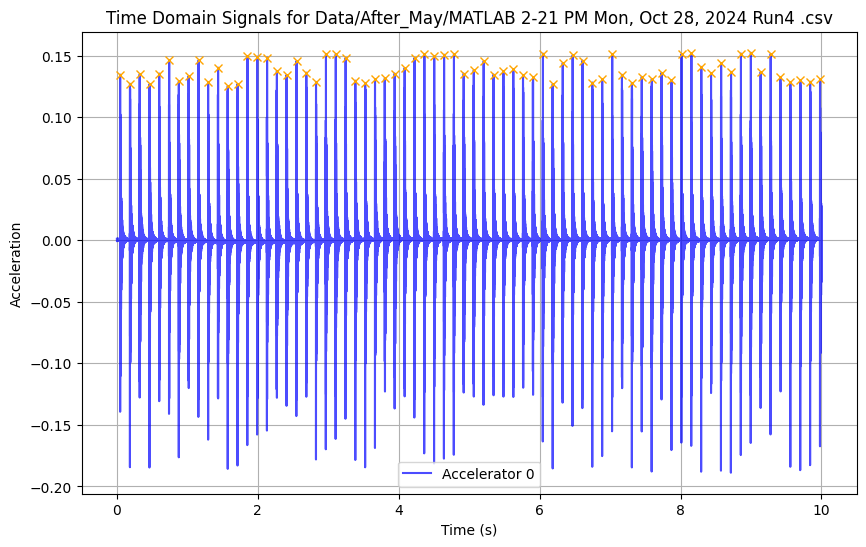

In [365]:
# file = 'Data/After_May/MATLAB 1-02 PM Thu, Nov 7, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-00 PM Fri, Jun 28, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-51 PM Tue, Oct 29, 2024 Run13 .csv'
# file = 'Data/After_May/MATLAB 2-45 PM Thu, Oct 24, 2024 Run10 .csv'
file = 'Data/After_May/MATLAB 1-25 PM Thu, Nov 7, 2024 Run11 .csv'
file = 'Data/After_May/MATLAB 2-21 PM Mon, Oct 28, 2024 Run4 .csv'
acceleration0 = get_file(file)
x, y = get_peaks(acceleration0)

plot_file(file)

In [366]:
diffs = []
for i in range(len(x)-1):
    for j in range(i+1, len(x)):
        diffs.append(float(x[j] - x[i]))
diffs.sort()
[round(x, 2) for x in diffs]

[0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.14,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.28,
 0.42,
 0.42,

In [367]:
# Test
# diffs = [1, 1.00001, 1.00002, 1.00004, 1.99999, 2, 2.00001, 2.00002, 2.5, 2.50000001, 2.50001, 2.50002]

50


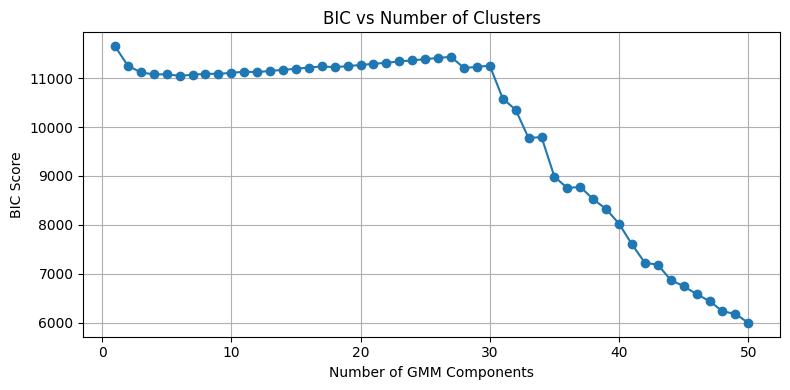

[{'mean': np.float64(0.13991126760563383),
  'sd': np.float64(0.001621992280054443),
  'n': 71},
 {'mean': np.float64(0.2798242857142857),
  'sd': np.float64(0.0019115764410025258),
  'n': 70},
 {'mean': np.float64(0.41978695652173914),
  'sd': np.float64(0.0023342387297328594),
  'n': 69},
 {'mean': np.float64(0.559725),
  'sd': np.float64(0.002895197595613623),
  'n': 68},
 {'mean': np.float64(0.6996686567164178),
  'sd': np.float64(0.003310327979206517),
  'n': 67},
 {'mean': np.float64(0.8396212121212121),
  'sd': np.float64(0.0039601237794978095),
  'n': 66},
 {'mean': np.float64(0.9795723076923076),
  'sd': np.float64(0.00437353958718908),
  'n': 65},
 {'mean': np.float64(1.1195828125),
  'sd': np.float64(0.004904225049877232),
  'n': 64},
 {'mean': np.float64(1.2595603174603176),
  'sd': np.float64(0.005505654803913319),
  'n': 63},
 {'mean': np.float64(1.3995822580645163),
  'sd': np.float64(0.005982812053076263),
  'n': 62},
 {'mean': np.float64(1.5395704918032787),
  'sd': np

In [368]:
def summarize_clusters(diffs, random_state=0):
    """
    Performs GMM clustering on diffs and returns a list of clusters sorted by mean.

    Each cluster is represented as a dictionary with keys:
    - 'mean': mean of the cluster
    - 'sd': standard deviation of the cluster
    - 'n': number of points in the cluster
    """
    min_components = 1
    max_components = min(50, max(2, len(diffs) // 5))
    print(max_components)
    # max_components = len(diffs) // 2

    X = np.array(diffs).reshape(-1, 1)
    bics, models = [], []

    # Fit models for different cluster counts
    for k in range(min_components, max_components + 1):
        model = GaussianMixture(n_components=k, random_state=random_state).fit(X)
        bics.append(model.bic(X))
        models.append(model)

    # Plot BIC values
    plt.figure(figsize=(8, 4))
    plt.plot(range(min_components, max_components + 1), bics, marker='o')
    plt.xlabel("Number of GMM Components")
    plt.ylabel("BIC Score")
    plt.title("BIC vs Number of Clusters")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Select best model
    best_index = np.argmin(bics)
    best_model = models[best_index]
    labels = best_model.predict(X)

    # Group values by cluster
    cluster_data = defaultdict(list)
    for val, label in zip(diffs, labels):
        cluster_data[label].append(val)

    # Create summary dictionaries
    clusters = []
    for values in cluster_data.values():
        values = np.array(values)
        if len(values) < 2:
            continue
        cluster_info = {
            'mean': np.mean(values),
            'sd': np.std(values),
            'n': len(values)
        }
        clusters.append(cluster_info)

    # Sort clusters by mean
    clusters.sort(key=lambda x: x['mean'])
    return clusters

# def summarize_clusters(diffs, jump_threshold=0.02):
#     """
#     Groups sorted diffs into clusters based on jumps larger than a threshold.
#
#     Parameters:
#     - diffs: list or array of time differences
#     - jump_threshold: max allowed jump between consecutive values within a cluster
#
#     Returns:
#     - clusters: list of dictionaries with 'mean', 'sd', and 'n' per cluster
#     """
#     diffs = sorted(diffs)
#     clusters = []
#     current_cluster = [diffs[0]]
#
#     for prev, curr in zip(diffs, diffs[1:]):
#         if abs(curr - prev) > jump_threshold:
#             if len(current_cluster) >= 2:
#                 clusters.append({
#                     'mean': np.mean(current_cluster),
#                     'sd': np.std(current_cluster),
#                     'n': len(current_cluster)
#                 })
#             current_cluster = [curr]
#         else:
#             current_cluster.append(curr)
#
#     # Add the final cluster
#     if len(current_cluster) >= 2:
#         clusters.append({
#             'mean': np.mean(current_cluster),
#             'sd': np.std(current_cluster),
#             'n': len(current_cluster)
#         })
#
#     return clusters


clusters = summarize_clusters(diffs)
clusters

In [369]:
from math import sqrt
from scipy.stats import norm

def prob_integer_multiple(base, sd_base, n_base, candidate, sd_candidate, n_candidate):
    """
    Computes the probability that the candidate mean is an integer multiple of the base mean,
    using propagated standard error.

    Parameters:
    - base, sd_base, n_base: mean, std, and sample size of base cluster
    - candidate, sd_candidate, n_candidate: same for candidate cluster

    Returns:
    - best_k: closest integer multiple
    - probability: two-tailed probability that ratio ≈ k
    """
    ratio = candidate / base
    best_k = round(ratio)

    # Use standard error (not just std dev)
    se_base = sd_base / sqrt(n_base)
    se_candidate = sd_candidate / sqrt(n_candidate)

    # Error propagation for ratio
    ratio_se = ratio * sqrt((se_candidate / candidate)**2 + (se_base / base)**2)

    z = abs(ratio - best_k) / ratio_se
    probability = 2 * (1 - norm.cdf(z))  # two-tailed

    return probability


In [370]:
def remove_integer_multiples(clusters, p_thresh=0.05):
    keep = [True] * len(clusters)

    for i in range(len(clusters) - 1):
        if not keep[i]:
            continue
        for j in range(i + 1, len(clusters)):
            if not keep[j]:
                continue

            ci = clusters[i]
            cj = clusters[j]

            p = prob_integer_multiple(
                base=ci["mean"], sd_base=ci["sd"], n_base=ci["n"],
                candidate=cj["mean"], sd_candidate=cj["sd"], n_candidate=cj["n"]
            )

            if p > p_thresh:
                # cluster_j is likely an integer multiple of cluster_i
                keep[j] = False

    # Return only the kept clusters
    pruned = [c for c, k in zip(clusters, keep) if k]
    return pruned

base_diffs = remove_integer_multiples(clusters)
base_diffs

[{'mean': np.float64(0.13991126760563383),
  'sd': np.float64(0.001621992280054443),
  'n': 71},
 {'mean': np.float64(4.1295), 'sd': np.float64(0.07102542709563699), 'n': 85},
 {'mean': np.float64(4.829665333333334),
  'sd': np.float64(0.07107614038167488),
  'n': 75},
 {'mean': np.float64(5.669404761904763),
  'sd': np.float64(0.07096678281448691),
  'n': 63},
 {'mean': np.float64(5.94927966101695),
  'sd': np.float64(0.07090512347833765),
  'n': 59},
 {'mean': np.float64(6.228916363636364),
  'sd': np.float64(0.0707997425871961),
  'n': 55},
 {'mean': np.float64(6.508494117647059),
  'sd': np.float64(0.07069675204499606),
  'n': 51},
 {'mean': np.float64(6.788048936170211),
  'sd': np.float64(0.07066735040852946),
  'n': 47},
 {'mean': np.float64(7.487070270270269),
  'sd': np.float64(0.07045104439739494),
  'n': 37},
 {'mean': np.float64(8.185588888888889),
  'sd': np.float64(0.07013164517050051),
  'n': 27},
 {'mean': np.float64(8.882682352941178),
  'sd': np.float64(0.069855508311

In [371]:
import numpy as np
from scipy.stats import norm

def count_hits_with_optimal_start(
    x, delta_t, sd, n, confidence=0.95, max_starts=10, extra_margin=0.00405
):
    import numpy as np
    from scipy.stats import norm

    x = np.array(x)
    se = sd / np.sqrt(n)
    z = norm.ppf(1 - (1 - confidence) / 2)
    margin = z * se + extra_margin

    best_hits = []
    best_tries = 0
    best_anchor = x[0]

    for i in range(min(max_starts, len(x))):
        anchor = x[i]
        hit_indices = []
        tries = 0
        k = 0

        while True:
            t = anchor + k * delta_t
            if t > x[-1]:
                break

            # Find all x values within the margin of the expected time t
            candidates = np.where((x >= t - margin) & (x <= t + margin))[0]
            if candidates.size > 0:
                hit_indices.append(candidates[0])  # take the first match

            tries += 1
            k += 1

        if len(hit_indices) > len(best_hits):
            best_hits = hit_indices
            best_tries = tries
            best_anchor = anchor

    # print("Hit indices:", best_hits)
    return delta_t, best_anchor, len(best_hits), best_tries



hit_lst = []
for i in range(len(base_diffs)):
    base_diff = base_diffs[i]
    delta_t, anchor, hits, tries = count_hits_with_optimal_start(x, base_diff["mean"], base_diff["sd"], base_diff["n"])
    hit_lst.append({"delta_t": float(round(delta_t, 4)), "anchor": float(anchor), "hits": hits, "tries": tries})

hit_lst

[{'delta_t': 0.1399, 'anchor': 1.2952, 'hits': 24, 'tries': 63},
 {'delta_t': 4.1295, 'anchor': 0.0464, 'hits': 2, 'tries': 3},
 {'delta_t': 4.8297, 'anchor': 0.0464, 'hits': 2, 'tries': 3},
 {'delta_t': 5.6694, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 5.9493, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 6.2289, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 6.5085, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 6.788, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 7.4871, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 8.1856, 'anchor': 0.0464, 'hits': 1, 'tries': 2},
 {'delta_t': 8.8827, 'anchor': 0.0464, 'hits': 1, 'tries': 2}]

In [372]:
x

array([0.0464, 0.1858, 0.3235, 0.463 , 0.601 , 0.7423, 0.8794, 1.0174,
       1.1588, 1.2952, 1.4366, 1.5739, 1.7129, 1.8535, 1.9927, 2.132 ,
       2.2711, 2.4079, 2.5496, 2.6888, 2.8265, 2.9675, 3.1069, 3.2465,
       3.3847, 3.5243, 3.6638, 3.8025, 3.9421, 4.0842, 4.2243, 4.3643,
       4.5042, 4.6442, 4.7843, 4.9221, 5.0655, 5.206 , 5.3462, 5.4864,
       5.6266, 5.7643, 5.9069, 6.0474, 6.1863, 6.3283, 6.4687, 6.6092,
       6.748 , 6.8884, 7.0305, 7.1686, 7.3099, 7.4494, 7.5924, 7.7305,
       7.8718, 8.014 , 8.1544, 8.2949, 8.4331, 8.5763, 8.717 , 8.8578,
       8.9985, 9.1366, 9.2795, 9.4175, 9.559 , 9.7011, 9.8398, 9.9801])